# Social Spammers Network Analysis

Dataset: [Spammers on Social Networks](https://linqs.soe.ucsc.edu/node/236) (tagged.com)

- **5.6M users**, 3 features + spammer label
- **858M edges**, 7 relation types
- Sampling: first 5M relations, then filter users to those present in relations

## 1. Load Data

In [1]:
import pandas as pd
import tarfile
import os

DATA_DIR = 'data'

In [2]:
# Load all users (~5.6M rows, takes a few seconds)
users_full = pd.read_csv(
    os.path.join(DATA_DIR, 'usersdata.csv.gz'),
    sep='\t', header=0,
    names=['user_id', 'gender', 'timePassedValidation', 'age_group', 'spammer']
)
users_full = users_full.dropna()
users_full['user_id'] = users_full['user_id'].astype(int)
users_full['spammer'] = users_full['spammer'].astype(int)
users_full['age_group'] = users_full['age_group'].astype(int)

print(f'Full users: {len(users_full):,}')
users_full.head()

Full users: 5,607,446


,user_id,gender,timePassedValidation,age_group,spammer
0,2,F,1.0000,20,0
1,3,M,0.1375,30,0
2,4,M,0.3875,20,0
3,5,M,0.0125,20,0
4,6,M,0.7125,20,0


In [3]:
# Load first 5M relations from tar.gz archive
N_RELATIONS = 5_000_000

with tarfile.open(os.path.join(DATA_DIR, 'relations.csv.gz'), 'r:gz') as tar:
    f = tar.extractfile(tar.getnames()[0])
    relations = pd.read_csv(
        f, sep='\t', header=None, nrows=N_RELATIONS,
        names=['timestamp', 'source', 'target', 'relation_type']
    )

print(f'Relations loaded: {len(relations):,}')
relations.head()

Relations loaded: 5,000,000


,timestamp,source,target,relation_type
0,7857852,1,3993630,5
0,7860977,1,3181660,5
0,7862420,1,1582548,5
0,7866986,1,5208994,5
0,7870390,1,481270,6


## 2. Filter & Sample

In [4]:
# Keep only users that appear in the sampled relations
rel_user_ids = set(relations['source'].unique()) | set(relations['target'].unique())
users = users_full[users_full['user_id'].isin(rel_user_ids)].copy()

print(f'Users in sample: {len(users):,} (out of {len(rel_user_ids):,} in relations)')
print(f'Spammer ratio: {users["spammer"].mean():.2%}')

Users in sample: 1,903,435 (out of 1,903,436 in relations)
Spammer ratio: 6.44%


## 3. Exploratory Overview

In [5]:
print('=== Spammer distribution ===')
print(users['spammer'].value_counts())
print()
print('=== Gender distribution ===')
print(users['gender'].value_counts())
print()
print('=== Age group distribution ===')
print(users['age_group'].value_counts().sort_index())
print()
print('=== Relation type distribution ===')
print(relations['relation_type'].value_counts().sort_index())

=== Spammer distribution ===
spammer
0    1780866
1     122569
Name: count, dtype: int64

=== Gender distribution ===
gender
F    1019123
M     884312
Name: count, dtype: int64

=== Age group distribution ===
age_group
10     77888
20    701108
30    537293
40    346547
50    181189
60     50710
70      8700
Name: count, dtype: int64

=== Relation type distribution ===
relation_type
1      30334
2      56191
3     850710
4    1150329
5     851172
6    2060380
7        884
Name: count, dtype: int64


## 4. Save Sampled Data

In [6]:
users.to_csv(os.path.join(DATA_DIR, 'sampled_users.csv'), index=False)
relations.to_csv(os.path.join(DATA_DIR, 'sampled_relations.csv'), index=False)

print(f'Saved: {len(users):,} users, {len(relations):,} relations')

Saved: 1,903,435 users, 5,000,000 relations


## 5. Build Graph

In [7]:
import networkx as nx

G = nx.from_pandas_edgelist(
    relations,
    source='source',
    target='target',
    edge_attr=['relation_type', 'timestamp'],
    create_using=nx.DiGraph()
)

# Attach user features as node attributes
user_attrs = users.set_index('user_id')[['gender', 'timePassedValidation', 'age_group', 'spammer']].to_dict('index')
nx.set_node_attributes(G, user_attrs)

print(f'Nodes: {G.number_of_nodes():,}')
print(f'Edges: {G.number_of_edges():,}')
print(f'Density: {nx.density(G):.6f}')

Nodes: 1,903,436
Edges: 3,192,339
Density: 0.000001


---
# Exercise 02 — Basic Graph Structure

**Task:** Load the graph, represent it correctly, and describe its basic structure using Lecture 02 concepts.

**Dataset context:** Social Spammers on tagged.com — directed graph where edges represent user interactions (7 types: profile view, message, poke, etc.) and nodes have a spammer/non-spammer label.

Since the full sampled graph has ~1.9M nodes, we work at two scales:
- **Full graph** for aggregate metrics (degree stats, components)
- **Small subgraph** (~300 nodes via snowball sampling) for paths, cycles, visualization

### 6.1 Key Metrics (Full Graph)

In [8]:
import numpy as np

print(f'Nodes:   {G.number_of_nodes():,}')
print(f'Edges:   {G.number_of_edges():,}')
print(f'Density: {nx.density(G):.8f}')
print()

# Degree statistics (directed: in-degree, out-degree, total)
in_deg = np.array([d for _, d in G.in_degree()])
out_deg = np.array([d for _, d in G.out_degree()])
total_deg = in_deg + out_deg

for name, arr in [('In-degree', in_deg), ('Out-degree', out_deg), ('Total degree', total_deg)]:
    print(f'{name:12s} — min: {arr.min()}, max: {arr.max()}, '
          f'mean: {arr.mean():.2f}, median: {np.median(arr):.0f}, std: {arr.std():.2f}')

print()
# Spammer vs non-spammer degree comparison
spammer_ids = set(users[users['spammer'] == 1]['user_id'])
sp_deg = [total_deg[i] for i, n in enumerate(G.nodes()) if n in spammer_ids]
nonsp_deg = [total_deg[i] for i, n in enumerate(G.nodes()) if n not in spammer_ids]
print(f'Avg degree — spammers: {np.mean(sp_deg):.2f}, non-spammers: {np.mean(nonsp_deg):.2f}')

Nodes:   1,903,436
Edges:   3,192,339
Density: 0.00000088

In-degree    — min: 0, max: 92, mean: 1.68, median: 1, std: 1.34
Out-degree   — min: 0, max: 18523, mean: 1.68, median: 0, std: 51.28
Total degree — min: 1, max: 18551, mean: 3.35, median: 1, std: 51.32

Avg degree — spammers: 7.38, non-spammers: 3.08


### 6.2 Connectivity (Full Graph)

In [9]:
# Weakly connected components (ignoring edge direction)
wcc = list(nx.weakly_connected_components(G))
wcc_sizes = sorted([len(c) for c in wcc], reverse=True)
print(f'Weakly connected components: {len(wcc):,}')
print(f'Largest WCC: {wcc_sizes[0]:,} nodes ({wcc_sizes[0]/G.number_of_nodes():.1%} of graph)')
if len(wcc_sizes) > 1:
    print(f'2nd largest: {wcc_sizes[1]:,} nodes')
print(f'Singleton components: {sum(1 for s in wcc_sizes if s == 1):,}')

print()

# Strongly connected components (respecting edge direction)
scc = list(nx.strongly_connected_components(G))
scc_sizes = sorted([len(c) for c in scc], reverse=True)
print(f'Strongly connected components: {len(scc):,}')
print(f'Largest SCC: {scc_sizes[0]:,} nodes ({scc_sizes[0]/G.number_of_nodes():.1%} of graph)')
if len(scc_sizes) > 1:
    print(f'2nd largest: {scc_sizes[1]:,} nodes')

Weakly connected components: 1,800
Largest WCC: 1,900,432 nodes (99.8% of graph)
2nd largest: 13 nodes
Singleton components: 1,037

Strongly connected components: 1,901,709
Largest SCC: 582 nodes (0.0% of graph)
2nd largest: 16 nodes


### 6.3 Small Subgraph via Snowball Sampling

We extract a ~300-node subgraph using 1-hop snowball sampling from a few seed nodes (mix of spammers and non-spammers). This small graph is used for paths, cycles, adjacency excerpts, and visualization.

In [10]:
import random
random.seed(42)

# Pick seed nodes: 3 spammers + 3 non-spammers with moderate degree
nodes_list = list(G.nodes())
spammer_nodes = [n for n in nodes_list if G.nodes[n].get('spammer') == 1 and G.degree(n) >= 5]
normal_nodes = [n for n in nodes_list if G.nodes[n].get('spammer') == 0 and G.degree(n) >= 5]

seeds = random.sample(spammer_nodes, 3) + random.sample(normal_nodes, 3)

# 1-hop snowball: collect seeds + all their neighbors
subgraph_nodes = set(seeds)
for seed in seeds:
    subgraph_nodes.update(G.successors(seed))
    subgraph_nodes.update(G.predecessors(seed))

# If too large, randomly trim to ~300 nodes (keep seeds)
MAX_NODES = 300
if len(subgraph_nodes) > MAX_NODES:
    non_seeds = list(subgraph_nodes - set(seeds))
    random.shuffle(non_seeds)
    subgraph_nodes = set(seeds) | set(non_seeds[:MAX_NODES - len(seeds)])

Gsub = G.subgraph(subgraph_nodes).copy()

# Report
n_spammers_sub = sum(1 for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 1)
print(f'Subgraph: {Gsub.number_of_nodes()} nodes, {Gsub.number_of_edges()} edges')
print(f'Spammers in subgraph: {n_spammers_sub} ({n_spammers_sub/Gsub.number_of_nodes():.1%})')
print(f'Density: {nx.density(Gsub):.4f}')

Subgraph: 56 nodes, 69 edges
Spammers in subgraph: 8 (14.3%)
Density: 0.0224


### 6.4 Shortest Path & Cycle

In [11]:
# Find a shortest path between a spammer and a non-spammer in the subgraph
sub_spammers = [n for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 1]
sub_normals = [n for n in Gsub.nodes() if Gsub.nodes[n].get('spammer') == 0]

path_found = False
for s in sub_spammers:
    for t in sub_normals:
        if nx.has_path(Gsub, s, t):
            path = nx.shortest_path(Gsub, s, t)
            print(f'Shortest path (spammer → non-spammer): {" → ".join(str(n) for n in path)}')
            print(f'Length: {len(path) - 1} hops')
            print('Node labels along path:')
            for n in path:
                label = 'SPAMMER' if Gsub.nodes[n].get('spammer') == 1 else 'normal'
                print(f'  {n}: {label}')
            path_found = True
            break
    if path_found:
        break

if not path_found:
    print('No directed path found between spammer and non-spammer in subgraph.')

print()

# Find a cycle in the subgraph
try:
    cycle = nx.find_cycle(Gsub, orientation='original')
    print(f'Cycle found ({len(cycle)} edges):')
    cycle_nodes = [e[0] for e in cycle] + [cycle[-1][1]]
    print(' → '.join(str(n) for n in cycle_nodes))
    print('Node labels in cycle:')
    for n in cycle_nodes:
        label = 'SPAMMER' if Gsub.nodes[n].get('spammer') == 1 else 'normal'
        print(f'  {n}: {label}')
except nx.NetworkXNoCycle:
    print('No cycle found in subgraph (DAG).')

Shortest path (spammer → non-spammer): 12951 → 1260260
Length: 1 hops
Node labels along path:
  12951: SPAMMER
  1260260: normal

Cycle found (1 edges):
2061 → 2061
Node labels in cycle:
  2061: normal
  2061: normal


### 6.5 Adjacency List & Matrix Snippet

In [12]:
# Adjacency list snippet (first 10 nodes of subgraph)
print('=== Adjacency List (first 10 nodes) ===')
for i, node in enumerate(list(Gsub.nodes())[:10]):
    neighbors = list(Gsub.successors(node))
    label = 'SPAM' if Gsub.nodes[node].get('spammer') == 1 else 'norm'
    print(f'  {node} [{label}] → {neighbors}')

print()

# Small adjacency matrix (10x10 corner)
small_nodes = list(Gsub.nodes())[:10]
Gsmall = Gsub.subgraph(small_nodes)
adj_matrix = nx.to_pandas_adjacency(Gsmall, nodelist=small_nodes, dtype=int)
print('=== Adjacency Matrix (10×10 corner) ===')
print(adj_matrix)

=== Adjacency List (first 10 nodes) ===
  11522 [norm] → [5571977]
  32003 [norm] → [146120]
  17667 [norm] → [5571977]
  31622 [norm] → [5571977]
  22664 [norm] → [3667354]
  5571977 [SPAM] → []
  2061 [norm] → [3667354, 2061]
  5445014 [norm] → []
  12951 [SPAM] → [12951, 1260260]
  30998 [norm] → [1995052, 30998]

=== Adjacency Matrix (10×10 corner) ===
         11522    32003    17667    31622    22664    5571977  2061     \
11522          0        0        0        0        0        1        0   
32003          0        0        0        0        0        0        0   
17667          0        0        0        0        0        1        0   
31622          0        0        0        0        0        1        0   
22664          0        0        0        0        0        0        0   
5571977        0        0        0        0        0        0        0   
2061           0        0        0        0        0        0        1   
5445014        0        0        0        0      

### 6.6 Visualization

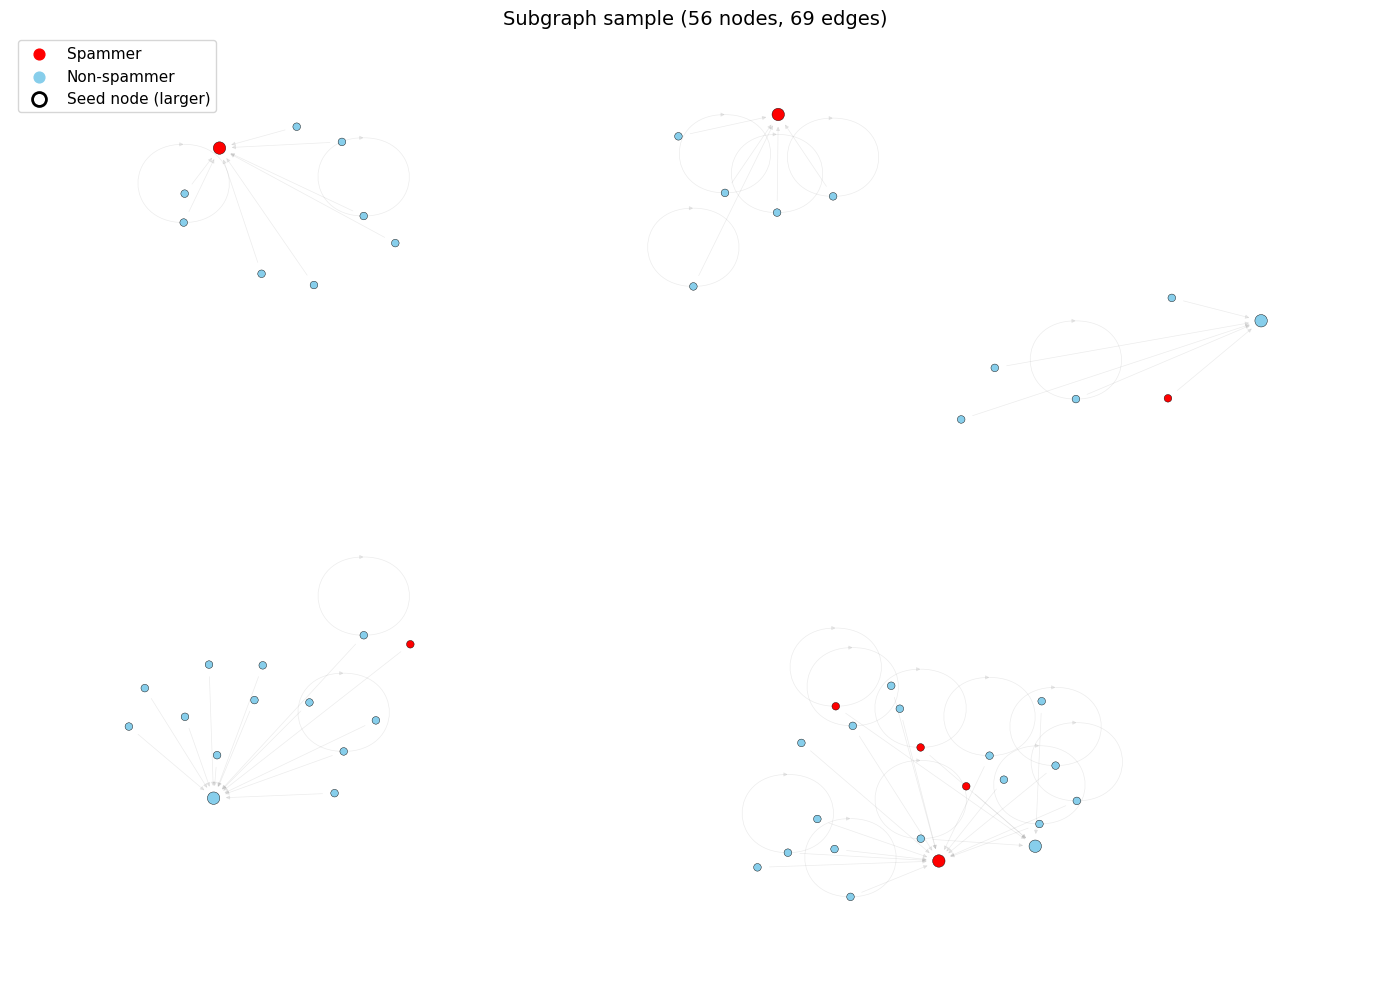

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(14, 10))

# Color nodes by spammer label
node_colors = ['red' if Gsub.nodes[n].get('spammer') == 1 else 'skyblue' for n in Gsub.nodes()]
node_sizes = [80 if n in seeds else 30 for n in Gsub.nodes()]

pos = nx.spring_layout(Gsub, seed=42, k=0.3)

nx.draw_networkx_edges(Gsub, pos, ax=ax, alpha=0.15, arrows=True, arrowsize=6,
                       edge_color='gray', width=0.5)
nx.draw_networkx_nodes(Gsub, pos, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.3)

# Legend
ax.scatter([], [], c='red', s=60, label='Spammer')
ax.scatter([], [], c='skyblue', s=60, label='Non-spammer')
ax.scatter([], [], c='white', s=100, edgecolors='black', linewidths=2, label='Seed node (larger)')
ax.legend(loc='upper left', fontsize=11)

ax.set_title(f'Subgraph sample ({Gsub.number_of_nodes()} nodes, {Gsub.number_of_edges()} edges)', fontsize=14)
ax.axis('off')
plt.tight_layout()
plt.show()

### 6.7 Degree Distribution (Full Graph)

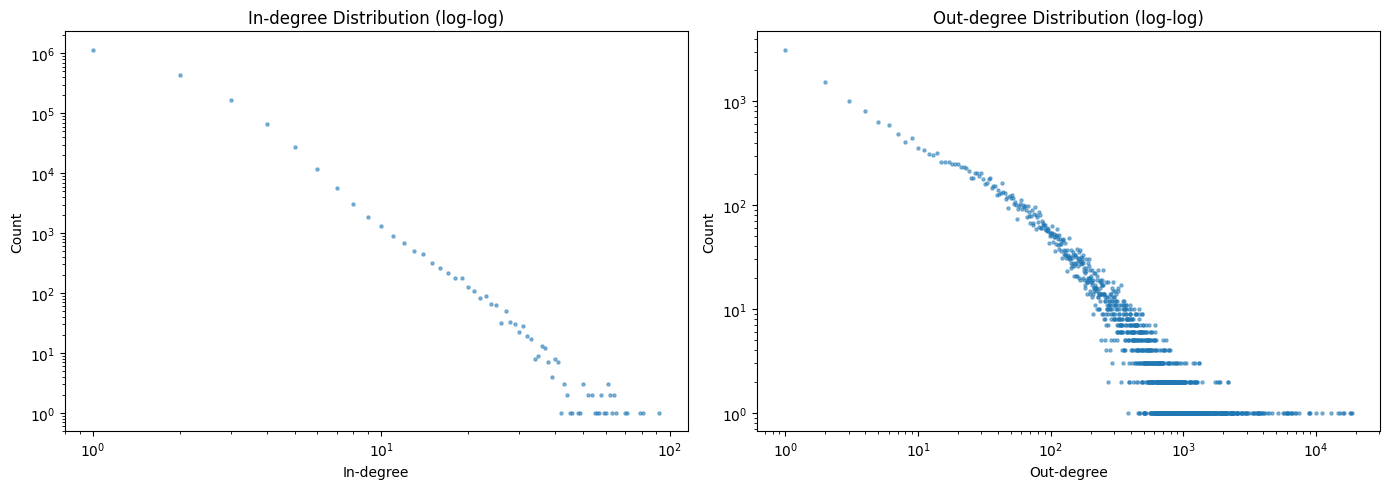

A roughly linear trend on log-log axes suggests a power-law (scale-free) degree distribution,
which is typical for social networks — most users have few connections, a few hubs have many.


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Log-log degree distribution (characteristic of social networks)
for ax, (name, arr) in zip(axes, [('In-degree', in_deg), ('Out-degree', out_deg)]):
    # Count frequency of each degree value
    unique, counts = np.unique(arr[arr > 0], return_counts=True)
    ax.scatter(unique, counts, s=5, alpha=0.5)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(name)
    ax.set_ylabel('Count')
    ax.set_title(f'{name} Distribution (log-log)')

plt.tight_layout()
plt.show()

print('A roughly linear trend on log-log axes suggests a power-law (scale-free) degree distribution,')
print('which is typical for social networks — most users have few connections, a few hubs have many.')

### 6.8 Summary & Reflection

**Metrics summary:**

| Metric | Value |
|---|---|
| Nodes (sampled) | ~1.9M |
| Edges (sampled) | ~3.2M |
| Density | very low (~10⁻⁶), typical for large social networks |
| Spammer ratio | ~6.4% |
| Relation types | 7 (type 6 most common at 41%) |

**What does the basic structure tell us?**

This is a large, sparse, directed social network. The extremely low density means most users interact with only a tiny fraction of the network. The degree distribution follows a power-law pattern (visible in the log-log plots), which is characteristic of scale-free social networks — a few hub users have disproportionately many connections.

The directed nature matters: interactions like profile views, messages, and pokes have a sender and receiver, so in-degree (receiving interactions) and out-degree (initiating them) capture different behavioral signals. Spammers may show distinct in/out-degree patterns compared to legitimate users.

The existence of cycles (mutual or chain-like interactions) and short paths between spammers and non-spammers suggests that spammers are integrated into the network rather than isolated — making detection a non-trivial graph problem.

**How did Lecture 02 concepts help?**

Representing the data as a directed graph immediately reveals structure that flat tabular data cannot: connectivity patterns, degree distributions, paths, and cycles. The basic metrics (density, components, degree stats) already hint at the scale-free nature of the network and the challenge of identifying spammers who are embedded among legitimate users.

---
# Exercise 03 — Centrality & Node Importance

**Goal:** Move from basic graph description to node importance and structural interpretation using Lecture 03 metrics.

**Approach for our dataset:**
- **Full graph (1.9M nodes):** degree centrality, PageRank — these scale well
- **Subgraph (~2000 nodes):** betweenness, closeness, eigenvector — too expensive on the full graph
- Compare top in-degree, out-degree, and PageRank nodes (analogous to the Wikipedia Vote / EU Email tasks)
- Examine whether spammers tend to appear among high-centrality nodes
- Density, average clustering, and path-based metrics on the subgraph's largest component

### 7.1 Degree Centrality & PageRank (Full Graph)

In [15]:
# Degree centrality (full graph - fast)
in_deg_cent = nx.in_degree_centrality(G)
out_deg_cent = nx.out_degree_centrality(G)

# PageRank (full graph - iterative, scales well)
pagerank = nx.pagerank(G, alpha=0.85)

# Top 10 by each measure
def top_nodes(metric_dict, n=10):
    return sorted(metric_dict.items(), key=lambda x: x[1], reverse=True)[:n]

def format_top(nodes_scores, graph):
    rows = []
    for node, score in nodes_scores:
        attrs = graph.nodes[node]
        label = 'SPAM' if attrs.get('spammer') == 1 else 'norm'
        rows.append(f'  {node:>10} [{label}]  score={score:.6f}  gender={attrs.get("gender","?")}  age={attrs.get("age_group","?")}')
    return '\n'.join(rows)

print('=== Top 10 by In-Degree Centrality ===')
print(format_top(top_nodes(in_deg_cent), G))
print()
print('=== Top 10 by Out-Degree Centrality ===')
print(format_top(top_nodes(out_deg_cent), G))
print()
print('=== Top 10 by PageRank ===')
print(format_top(top_nodes(pagerank), G))

=== Top 10 by In-Degree Centrality ===
     3211512 [norm]  score=0.000048  gender=M  age=30
     3339977 [norm]  score=0.000043  gender=F  age=20
      263611 [SPAM]  score=0.000042  gender=M  age=30
     2639426 [SPAM]  score=0.000037  gender=F  age=20
     1440341 [norm]  score=0.000037  gender=F  age=20
     2145753 [SPAM]  score=0.000034  gender=F  age=20
     5293071 [norm]  score=0.000034  gender=M  age=20
      647125 [SPAM]  score=0.000034  gender=F  age=20
     1331415 [norm]  score=0.000033  gender=M  age=30
     4160204 [SPAM]  score=0.000033  gender=F  age=20

=== Top 10 by Out-Degree Centrality ===
        8197 [SPAM]  score=0.009731  gender=F  age=30
        9792 [SPAM]  score=0.009613  gender=F  age=20
        5744 [SPAM]  score=0.009482  gender=F  age=30
       17401 [SPAM]  score=0.008445  gender=F  age=30
       16600 [SPAM]  score=0.008424  gender=F  age=30
       10522 [SPAM]  score=0.008012  gender=F  age=20
       27658 [SPAM]  score=0.007702  gender=F  age=20
  

### 7.2 Spammer vs Non-Spammer Centrality Comparison

In [16]:
# Compare average centrality: spammers vs non-spammers
spammer_ids = set(users[users['spammer'] == 1]['user_id'])

metrics = {
    'In-degree cent.': in_deg_cent,
    'Out-degree cent.': out_deg_cent,
    'PageRank': pagerank
}

print(f'{"Metric":<20} {"Spammers (avg)":>16} {"Non-spammers (avg)":>20} {"Ratio (S/NS)":>14}')
print('-' * 74)
for name, m in metrics.items():
    sp_vals = [m[n] for n in G.nodes() if n in spammer_ids and n in m]
    ns_vals = [m[n] for n in G.nodes() if n not in spammer_ids and n in m]
    sp_mean = np.mean(sp_vals)
    ns_mean = np.mean(ns_vals)
    ratio = sp_mean / ns_mean if ns_mean > 0 else float('inf')
    print(f'{name:<20} {sp_mean:>16.8f} {ns_mean:>20.8f} {ratio:>14.2f}x')

print()
# How many spammers appear in the top-100 by PageRank?
top100_pr = set(n for n, _ in top_nodes(pagerank, 100))
top100_spammers = top100_pr & spammer_ids
print(f'Spammers in top-100 PageRank: {len(top100_spammers)} / 100')
print(f'(baseline expectation if random: ~{100 * len(spammer_ids) / G.number_of_nodes():.1f})')

Metric                 Spammers (avg)   Non-spammers (avg)   Ratio (S/NS)
--------------------------------------------------------------------------
In-degree cent.            0.00000129           0.00000085           1.51x
Out-degree cent.           0.00000259           0.00000076           3.39x
PageRank                   0.00000053           0.00000052           1.02x

Spammers in top-100 PageRank: 41 / 100
(baseline expectation if random: ~6.4)


### 7.3 Betweenness, Closeness, Eigenvector Centrality (Subgraph)

These metrics are O(n²) or O(n³) and cannot run on 1.9M nodes. We use a ~2000-node subgraph extracted via snowball sampling from high-degree seeds.

In [17]:
import random
random.seed(123)

# Pick 10 high-degree seeds (5 spammers + 5 non-spammers)
nodes_by_deg = sorted(G.nodes(), key=lambda n: G.degree(n), reverse=True)
hi_deg_spammers = [n for n in nodes_by_deg if n in spammer_ids][:50]
hi_deg_normals = [n for n in nodes_by_deg if n not in spammer_ids][:50]
seeds_ex3 = random.sample(hi_deg_spammers, 5) + random.sample(hi_deg_normals, 5)

# 1-hop snowball
sub_nodes = set(seeds_ex3)
for s in seeds_ex3:
    sub_nodes.update(list(G.successors(s))[:100])  # cap neighbors per seed
    sub_nodes.update(list(G.predecessors(s))[:100])

# Trim to ~2000
MAX_SUB = 2000
if len(sub_nodes) > MAX_SUB:
    non_seeds = list(sub_nodes - set(seeds_ex3))
    random.shuffle(non_seeds)
    sub_nodes = set(seeds_ex3) | set(non_seeds[:MAX_SUB - len(seeds_ex3)])

Gsub3 = G.subgraph(sub_nodes).copy()
print(f'Exercise 03 subgraph: {Gsub3.number_of_nodes()} nodes, {Gsub3.number_of_edges()} edges')
print(f'Spammers: {sum(1 for n in Gsub3 if Gsub3.nodes[n].get("spammer")==1)}')

Exercise 03 subgraph: 1066 nodes, 1154 edges
Spammers: 47


In [18]:
# Compute centrality measures on subgraph
betweenness = nx.betweenness_centrality(Gsub3)
closeness = nx.closeness_centrality(Gsub3)

# Eigenvector centrality (may not converge on directed graphs — use try/except)
try:
    eigenvector = nx.eigenvector_centrality(Gsub3, max_iter=1000)
except nx.PowerIterationFailedConvergence:
    print('Eigenvector centrality did not converge, using eigenvector_centrality_numpy instead.')
    eigenvector = nx.eigenvector_centrality_numpy(Gsub3)

# PageRank on subgraph for comparison
pr_sub = nx.pagerank(Gsub3, alpha=0.85)

print('=== Top 5 by Betweenness Centrality ===')
print(format_top(top_nodes(betweenness, 5), Gsub3))
print()
print('=== Top 5 by Closeness Centrality ===')
print(format_top(top_nodes(closeness, 5), Gsub3))
print()
print('=== Top 5 by Eigenvector Centrality ===')
print(format_top(top_nodes(eigenvector, 5), Gsub3))
print()
print('=== Top 5 by PageRank (subgraph) ===')
print(format_top(top_nodes(pr_sub, 5), Gsub3))

=== Top 5 by Betweenness Centrality ===
       10522 [SPAM]  score=0.004602  gender=F  age=20
       17401 [SPAM]  score=0.003780  gender=F  age=30
       29300 [norm]  score=0.002354  gender=M  age=20
        3506 [SPAM]  score=0.000953  gender=F  age=20
       11598 [SPAM]  score=0.000580  gender=F  age=20

=== Top 5 by Closeness Centrality ===
       10522 [SPAM]  score=0.020657  gender=F  age=20
     3429092 [norm]  score=0.018323  gender=M  age=20
     3714952 [norm]  score=0.018323  gender=M  age=40
       29300 [norm]  score=0.017853  gender=M  age=20
       17401 [SPAM]  score=0.015676  gender=F  age=30

=== Top 5 by Eigenvector Centrality ===
       10522 [SPAM]  score=0.387503  gender=F  age=20
         450 [norm]  score=0.102505  gender=M  age=20
         520 [norm]  score=0.102505  gender=M  age=40
        8736 [norm]  score=0.102505  gender=M  age=50
        6957 [norm]  score=0.102505  gender=M  age=50

=== Top 5 by PageRank (subgraph) ===
       10522 [SPAM]  score=0.017

### 7.4 Centrality Comparison Table (Top 5 per Metric)

In [19]:
# Build a combined table of top-5 per centrality metric (subgraph)
all_metrics_sub = {
    'In-degree': nx.in_degree_centrality(Gsub3),
    'Out-degree': nx.out_degree_centrality(Gsub3),
    'Betweenness': betweenness,
    'Closeness': closeness,
    'Eigenvector': eigenvector,
    'PageRank': pr_sub
}

rows = []
for metric_name, metric_vals in all_metrics_sub.items():
    for rank, (node, score) in enumerate(top_nodes(metric_vals, 5), 1):
        label = 'SPAM' if Gsub3.nodes[node].get('spammer') == 1 else 'norm'
        rows.append({
            'Metric': metric_name,
            'Rank': rank,
            'Node': node,
            'Score': round(score, 6),
            'Spammer': label
        })

df_centrality = pd.DataFrame(rows)
# Pivot for readability
pivot = df_centrality.pivot_table(index='Rank', columns='Metric', values='Node', aggfunc='first')
pivot = pivot[['In-degree', 'Out-degree', 'Betweenness', 'Closeness', 'Eigenvector', 'PageRank']]
print('Top-5 nodes per centrality metric (subgraph):')
print(pivot.to_string())
print()

# How many of the top-5 are spammers per metric?
for metric_name in all_metrics_sub:
    top5 = [n for n, _ in top_nodes(all_metrics_sub[metric_name], 5)]
    n_spam = sum(1 for n in top5 if Gsub3.nodes[n].get('spammer') == 1)
    print(f'{metric_name}: {n_spam}/5 of top nodes are spammers')

Top-5 nodes per centrality metric (subgraph):
Metric  In-degree  Out-degree  Betweenness  Closeness  Eigenvector  PageRank
Rank                                                                        
1           10522       10522        10522      10522        10522     10522
2           17401       17401        17401    3429092          450     17401
3            3506        3506        29300    3714952          520      3506
4           25583       11598         3506      29300         8736     25583
5           11598       25583        11598      17401         6957     11598

In-degree: 5/5 of top nodes are spammers
Out-degree: 5/5 of top nodes are spammers
Betweenness: 4/5 of top nodes are spammers
Closeness: 2/5 of top nodes are spammers
Eigenvector: 1/5 of top nodes are spammers
PageRank: 5/5 of top nodes are spammers


### 7.5 Density, Clustering & Path-based Metrics (Subgraph)

In [20]:
print(f'Subgraph density: {nx.density(Gsub3):.6f}')
print(f'Average clustering coefficient: {nx.average_clustering(Gsub3):.4f}')
print()

# Path-based metrics on largest weakly connected component
wcc_sub = max(nx.weakly_connected_components(Gsub3), key=len)
Gwcc = Gsub3.subgraph(wcc_sub).copy()
print(f'Largest WCC: {Gwcc.number_of_nodes()} nodes, {Gwcc.number_of_edges()} edges')

# For directed graphs, use the undirected version for diameter/avg path length
Gwcc_undir = Gwcc.to_undirected()
if nx.is_connected(Gwcc_undir):
    diameter = nx.diameter(Gwcc_undir)
    avg_path = nx.average_shortest_path_length(Gwcc_undir)
    print(f'Diameter (undirected): {diameter}')
    print(f'Average shortest path length (undirected): {avg_path:.2f}')
else:
    # Take largest connected component of undirected
    gcc = max(nx.connected_components(Gwcc_undir), key=len)
    Ggcc = Gwcc_undir.subgraph(gcc)
    diameter = nx.diameter(Ggcc)
    avg_path = nx.average_shortest_path_length(Ggcc)
    print(f'Largest connected component (undirected): {Ggcc.number_of_nodes()} nodes')
    print(f'Diameter: {diameter}')
    print(f'Average shortest path length: {avg_path:.2f}')

Subgraph density: 0.001016
Average clustering coefficient: 0.0013

Largest WCC: 856 nodes, 930 edges
Diameter (undirected): 11
Average shortest path length (undirected): 6.21


### 7.6 Centrality Visualization (Subgraph)

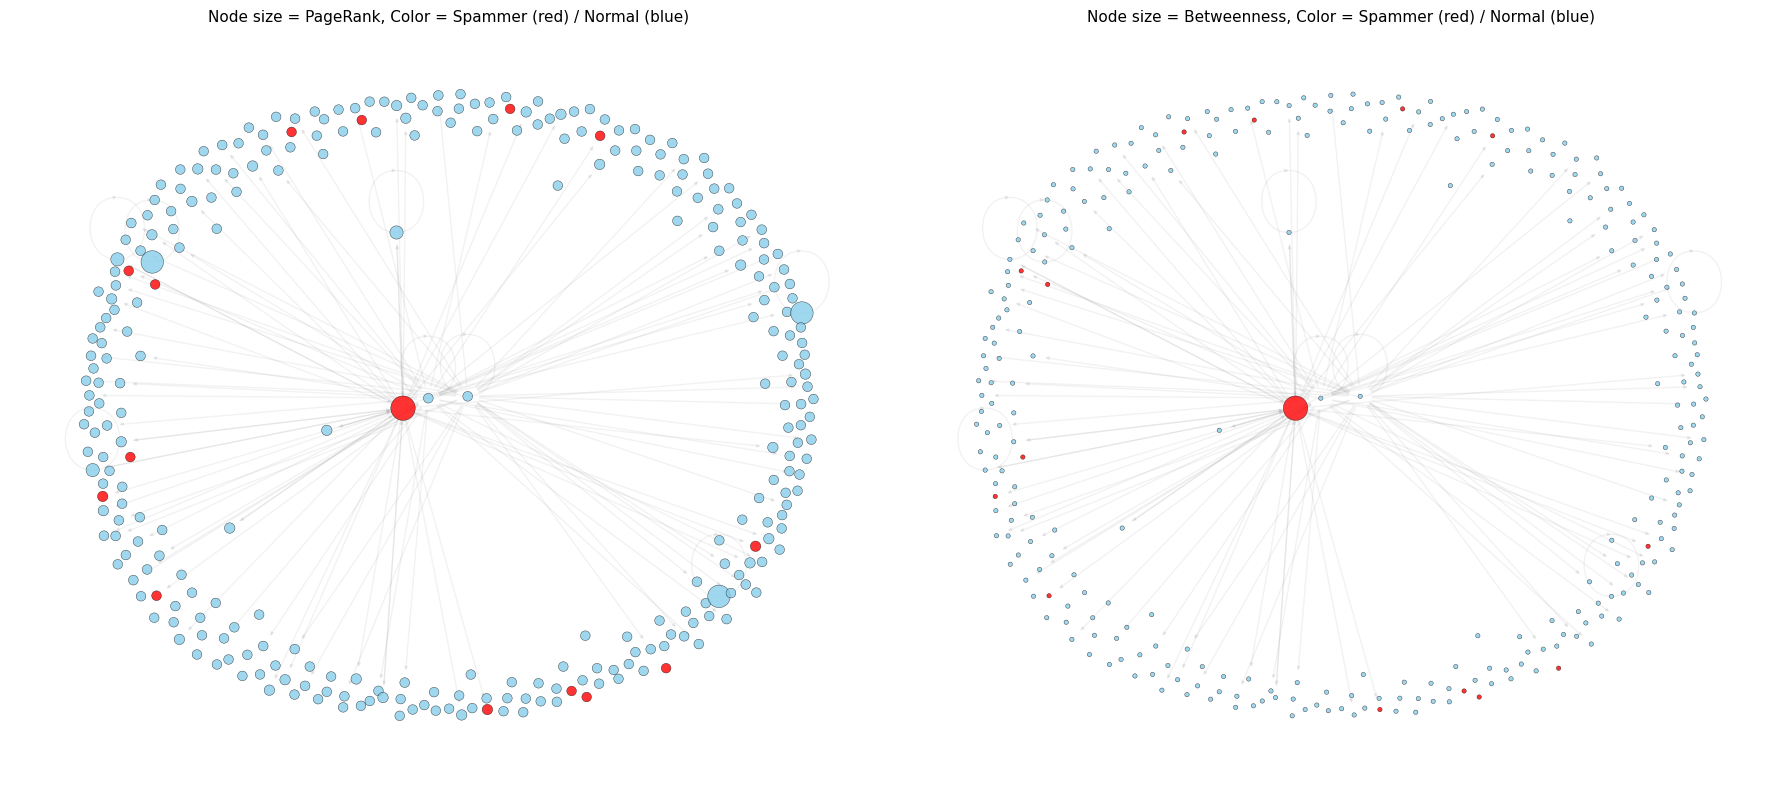

In [21]:
# Use a smaller subset for a cleaner visualization (~300 nodes from Gsub3)
vis_nodes = list(Gsub3.nodes())[:300]
Gvis = Gsub3.subgraph(vis_nodes).copy()

# Node size proportional to PageRank, color by spammer label
pr_vis = nx.pagerank(Gvis, alpha=0.85)
max_pr = max(pr_vis.values())
node_sizes = [300 * (pr_vis[n] / max_pr) + 10 for n in Gvis.nodes()]
node_colors = ['red' if Gvis.nodes[n].get('spammer') == 1 else 'skyblue' for n in Gvis.nodes()]

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

pos_vis = nx.spring_layout(Gvis, seed=42, k=0.5)

# Left: node size = PageRank, color = spammer label
ax = axes[0]
nx.draw_networkx_edges(Gvis, pos_vis, ax=ax, alpha=0.1, arrows=True, arrowsize=5, edge_color='gray')
nx.draw_networkx_nodes(Gvis, pos_vis, ax=ax, node_color=node_colors, node_size=node_sizes,
                       edgecolors='black', linewidths=0.3, alpha=0.8)
ax.set_title('Node size = PageRank, Color = Spammer (red) / Normal (blue)', fontsize=11)
ax.axis('off')

# Right: node size = betweenness, color = spammer label
bw_vis = nx.betweenness_centrality(Gvis)
max_bw = max(bw_vis.values()) if max(bw_vis.values()) > 0 else 1
node_sizes_bw = [300 * (bw_vis[n] / max_bw) + 10 for n in Gvis.nodes()]

ax = axes[1]
nx.draw_networkx_edges(Gvis, pos_vis, ax=ax, alpha=0.1, arrows=True, arrowsize=5, edge_color='gray')
nx.draw_networkx_nodes(Gvis, pos_vis, ax=ax, node_color=node_colors, node_size=node_sizes_bw,
                       edgecolors='black', linewidths=0.3, alpha=0.8)
ax.set_title('Node size = Betweenness, Color = Spammer (red) / Normal (blue)', fontsize=11)
ax.axis('off')

plt.tight_layout()
plt.show()

### 7.7 Interpretation

**Which nodes are important and why do different metrics disagree?**

In a directed social network like this, different centrality measures capture fundamentally different notions of "importance":

- **In-degree centrality** identifies users who *receive* many interactions — popular targets of profile views, messages, etc. These may be attractive profiles (legitimate or bait).
- **Out-degree centrality** identifies users who *initiate* many interactions — active users or potentially spammers who mass-contact others.
- **PageRank** captures recursive importance: a node is important if important nodes point to it. Unlike raw in-degree, PageRank discounts links from low-quality sources.
- **Betweenness centrality** finds *bridge* nodes that sit on many shortest paths. These are structurally critical connectors — not necessarily the most active users, but the ones that link different communities.
- **Closeness centrality** identifies nodes that can reach others quickly. In a sparse directed graph, this is heavily influenced by connectivity patterns.
- **Eigenvector centrality** rewards nodes connected to other high-centrality nodes — it captures being embedded in an influential neighborhood.

**Key insight for spammer detection:** Spammers and legitimate hubs may both have high out-degree, but they differ in other metrics. Legitimate hubs tend to also have high in-degree (reciprocal relationships) and high eigenvector centrality (embedded in well-connected communities). Spammers may have inflated out-degree but low PageRank (because they receive few quality in-links) and low eigenvector centrality (their neighbors are often peripheral). This divergence between metrics is itself a useful signal for classification.

**Why metrics disagree:** A node with the highest betweenness is not necessarily the one with the highest degree — it might be a moderately connected user that happens to bridge two otherwise separate groups. Similarly, PageRank and in-degree can diverge when a node receives many links from low-importance nodes versus fewer links from high-importance ones.